### Notebook 4. Predictive Modelling of Toronto Neighbourhood Vulnerability

This notebook develops and evaluates supervised machine learning models to predict neighbourhood-level low-income prevalence using selected socioeconomic indicators.

Building upon the cleaned analysis-ready dataset developed in Notebook 2 and the neighbourhood vulnerability profiles identified in Notebook 3, this notebook investigates the predictive relationship between socioeconomic characteristics and neighbourhood vulnerability.

The objective is to establish a baseline predictive modelling framework capable of estimating neighbourhood-level low-income prevalence while identifying the socioeconomic indicators that contribute most strongly to prediction accuracy.

### Section-1. Introduction

###  Research Question 3

### How accurately can neighbourhood socioeconomic vulnerability, measured by the Low Income After-Tax Percentage (LIM-AT), be predicted using selected socioeconomic indicators?

This notebook develops supervised machine learning models to estimate neighbourhood-level **Low Income After-Tax Percentage (LIM-AT)** using eleven socioeconomic predictor variables representing labour market participation, educational attainment, demographic composition, and housing conditions.

The resulting predictive models provide quantitative evidence regarding the ability of socioeconomic indicators to explain neighbourhood vulnerability and establish a baseline framework for future socioeconomic forecasting.

This notebook applies supervised machine learning techniques to predict the **Low Income After-Tax Percentage (LIM-AT)** for Toronto neighbourhoods using selected socioeconomic indicators.

The predictive models developed in this notebook provide quantitative evidence regarding the ability of socioeconomic variables to explain neighbourhood-level vulnerability and establish a baseline framework for future predictive socioeconomic modelling.

### Section-2. Input and Output

### Input

| File | Description |
|------|-------------|
| `neighbourhood_profiles_2016_analysis_ready.csv` | Cleaned analysis-ready dataset containing neighbourhood-level socioeconomic indicators and the target variable generated in Notebook 2. |

## Output

| File | Description |
|------|-------------|
| `neighbourhood_predictions.csv` | Actual and predicted neighbourhood low-income prevalence values. |
| `model_performance_summary.xlsx` | Summary of predictive model evaluation metrics. |
| `04_Predictive_Modelling.html` | HTML report documenting the complete predictive modelling workflow. |

The outputs generated in this notebook provide quantitative evidence supporting Research Question 3 and establish the predictive performance of selected socioeconomic indicators for estimating neighbourhood-level vulnerability across Toronto.

### Section-4. Import library Directory

In [45]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

## Section 5. Project Directory

In [46]:
# Project Directory

project_root = Path.cwd().parents[1]

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)
print(project_root)

PROJECT ROOT
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project


### Section-6. Load and Validate the Analysis-Ready Dataset

The cleaned analysis-ready dataset generated in Notebook 2 is loaded for predictive modelling.

Prior to model development, the dataset is validated to confirm the number of observations, variables, and the absence of missing values that could affect model performance.

In [47]:
# Load Modelling Dataset

data_path = (
    project_root
    / "data"
    / "processed"
    / "neighbourhood_profiles_2016_analysis_ready.csv")

df = pd.read_csv(data_path)

# Remove City of Toronto Aggregate Record

df = (
    df[df["Neighbourhood"] != "City of Toronto"]
    .reset_index(drop=True))

# Keep Variables Required for Predictive Modelling

selected_columns = [

    "Neighbourhood",
    "Population",

    "Participation_Rate",
    "Employment_Rate",
    "Unemployment_Rate",

    "Bachelors_Degree_Pct",
    "No_Diploma_Pct",

    "Immigrant_Population_Pct",
    "Visible_Minority_Pct",

    "Renters_Pct",

    "Core_Housing_Need",
    "Unaffordable_Housing",

    "Lone_Parent_Families_Pct",

    "Low_Income_AfterTax_Pct"]

df = df[selected_columns].copy()

print("=" * 60)
print("MODELLING DATASET LOADED")
print("=" * 60)

print(f"Observations : {df.shape[0]}")
print(f"Variables    : {df.shape[1]}")
print(f"Missing Values : {df.isnull().sum().sum()}")

display(df.head())

MODELLING DATASET LOADED
Observations : 140
Variables    : 14
Missing Values : 0


,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct,Low_Income_AfterTax_Pct
0,Agincourt North,29113,55.4,50.0,9.8,15.044825,25.624292,68.680658,90.560918,5.908014,2220,34.7,5.667571,21.3
1,Agincourt South-Malvern West,23757,59.0,53.2,9.8,17.721093,25.634550,63.539167,84.838153,9.470893,1795,38.2,5.724629,22.6
2,Alderwood,12054,66.5,62.4,6.1,13.771362,24.556164,32.935125,20.657043,7.881201,540,21.7,5.558321,8.2
3,Annex,30526,70.6,65.8,6.7,29.925310,13.988076,27.091660,23.815764,32.333093,2420,40.4,2.931927,18.3
4,Banbury-Don Mills,27695,59.9,55.6,7.2,23.469940,18.595414,47.643979,45.856653,17.096949,2115,33.4,4.531504,13.7


### Interpretation

The modelling dataset contains **140 Toronto neighbourhoods** and **14 variables**, including **11 socioeconomic predictor variables**, one descriptive population variable, the neighbourhood identifier, and the target variable representing neighbourhood socioeconomic vulnerability.

No missing values were detected, indicating that the dataset is complete and suitable for supervised machine learning without requiring additional data imputation or preprocessing.

The removal of the aggregate **City of Toronto** record ensures that the predictive models are trained exclusively on neighbourhood-level observations, thereby avoiding potential bias introduced by city-wide summary statistics.

### Section-7. Validate the Modelling Dataset

The modelling dataset is validated prior to predictive model development.

This validation confirms:

- the number of observations,
- the number of predictor variables,
- the target variable,
- the presence of missing values, and
- the variables selected for modelling.

These checks ensure that the dataset is suitable for supervised machine learning.

In [48]:
# Dataset Validation

print("=" * 60)
print("MODELLING DATASET VALIDATION")
print("=" * 60)

print(f"Observations        : {len(df)}")
print(f"Variables           : {len(df.columns)}")
print(f"Missing Values      : {df.isnull().sum().sum()}")
print(f"Target Variable     : Low_Income_AfterTax_Pct")

print("\nPredictor Variables")

predictors = [

    "Participation_Rate",
    "Employment_Rate",
    "Unemployment_Rate",
    "Bachelors_Degree_Pct",
    "No_Diploma_Pct",
    "Immigrant_Population_Pct",
    "Visible_Minority_Pct",
    "Renters_Pct",
    "Core_Housing_Need",
    "Unaffordable_Housing",
    "Lone_Parent_Families_Pct"]

for variable in predictors:
    print(f"• {variable}")

MODELLING DATASET VALIDATION
Observations        : 140
Variables           : 14
Missing Values      : 0
Target Variable     : Low_Income_AfterTax_Pct

Predictor Variables
• Participation_Rate
• Employment_Rate
• Unemployment_Rate
• Bachelors_Degree_Pct
• No_Diploma_Pct
• Immigrant_Population_Pct
• Visible_Minority_Pct
• Renters_Pct
• Core_Housing_Need
• Unaffordable_Housing
• Lone_Parent_Families_Pct


### Section-8. Define Predictor and Target Variables

The predictive modelling framework separates the modelling dataset into predictor variables (**X**) and the target variable (**y**).

The target variable is **Low Income After-Tax Percentage (LIM-AT)**, representing neighbourhood-level socioeconomic vulnerability.

The predictor variables consist of the eleven socioeconomic indicators identified through the statistical analyses performed in Notebook 2. These variables capture labour market participation, educational attainment, demographic composition, and housing characteristics that are expected to influence neighbourhood low-income prevalence.

In [49]:
# Predictor and Target Variables

predictor_variables = [

    "Participation_Rate",
    "Employment_Rate",
    "Unemployment_Rate",

    "Bachelors_Degree_Pct",
    "No_Diploma_Pct",

    "Immigrant_Population_Pct",
    "Visible_Minority_Pct",

    "Renters_Pct",

    "Core_Housing_Need",
    "Unaffordable_Housing",

    "Lone_Parent_Families_Pct"]

target_variable = "Low_Income_AfterTax_Pct"

X = df[predictor_variables].copy()

y = df[target_variable].copy()

print("=" * 60)
print("PREDICTOR AND TARGET VARIABLES CREATED")
print("=" * 60)

print(f"Predictor Variables : {X.shape[1]}")
print(f"Observations        : {X.shape[0]}")
print(f"Target Variable     : {target_variable}")

display(X.head())
display(y.head())

PREDICTOR AND TARGET VARIABLES CREATED
Predictor Variables : 11
Observations        : 140
Target Variable     : Low_Income_AfterTax_Pct


,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct
0,55.4,50.0,9.8,15.044825,25.624292,68.680658,90.560918,5.908014,2220,34.7,5.667571
1,59.0,53.2,9.8,17.721093,25.634550,63.539167,84.838153,9.470893,1795,38.2,5.724629
2,66.5,62.4,6.1,13.771362,24.556164,32.935125,20.657043,7.881201,540,21.7,5.558321
3,70.6,65.8,6.7,29.925310,13.988076,27.091660,23.815764,32.333093,2420,40.4,2.931927
4,59.9,55.6,7.2,23.469940,18.595414,47.643979,45.856653,17.096949,2115,33.4,4.531504


0    21.3
1    22.6
2     8.2
3    18.3
4    13.7
Name: Low_Income_AfterTax_Pct, dtype: float64

### Interpretation

The predictive modelling dataset consists of **11 independent variables** and **one dependent variable**.

The dependent variable, **Low Income After-Tax Percentage (LIM-AT)**, represents the quantitative proxy used to measure neighbourhood socioeconomic vulnerability.

The selected predictor variables represent four major dimensions of neighbourhood conditions:

- **Labour Market:** Participation Rate, Employment Rate, Unemployment Rate
- **Education:** Bachelor's Degree (%), No Diploma (%)
- **Demographic Composition:** Immigrant Population (%), Visible Minority (%), Lone-Parent Families (%)
- **Housing:** Renters (%), Core Housing Need, Unaffordable Housing

These predictors provide a comprehensive representation of neighbourhood socioeconomic characteristics and form the basis for the supervised machine learning models developed in the subsequent sections.

### Section-9. Exploratory Analysis of the Target Variable

Before developing predictive models, the target variable is examined to better understand the distribution of neighbourhood socioeconomic vulnerability.

Neighbourhood vulnerability is operationalized using the **Low Income After-Tax Percentage (LIM-AT)**, which serves as a quantitative proxy for socioeconomic vulnerability.

Descriptive statistics and graphical analysis are used to summarize the distribution of LIM-AT across Toronto neighbourhoods and to identify its range, central tendency, and variability prior to model development.

In [50]:
# Target Variable Summary Statistics

print("=" * 60)
print("TARGET VARIABLE SUMMARY")
print("=" * 60)

summary = y.describe().round(2)

display(summary)

TARGET VARIABLE SUMMARY


count    140.00
mean      19.51
std        7.89
min        4.50
25%       14.10
50%       18.55
75%       23.95
max       45.50
Name: Low_Income_AfterTax_Pct, dtype: float64

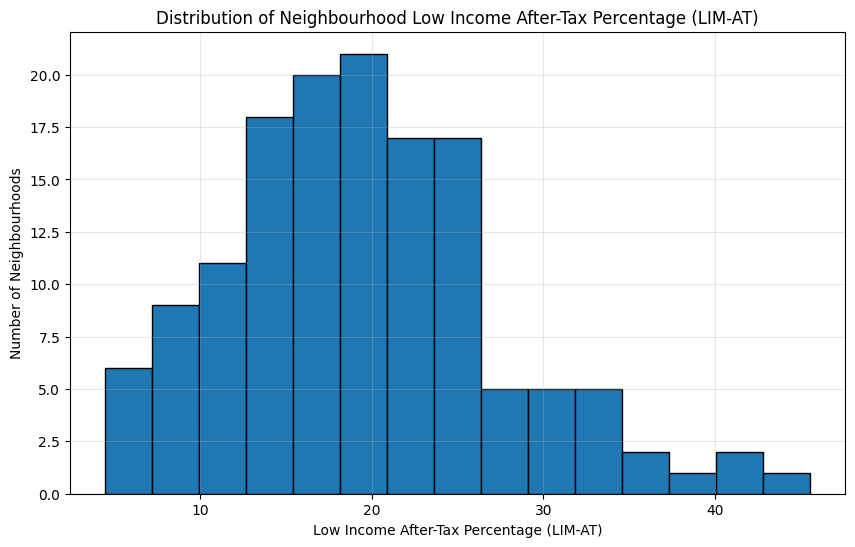

In [51]:
# Distribution of LIM-AT

plt.figure(figsize=(10,6))

plt.hist(
    y,
    bins=15,
    edgecolor="black")

plt.title("Distribution of Neighbourhood Low Income After-Tax Percentage (LIM-AT)")
plt.xlabel("Low Income After-Tax Percentage (LIM-AT)")
plt.ylabel("Number of Neighbourhoods")

plt.grid(alpha=0.3)

plt.show()

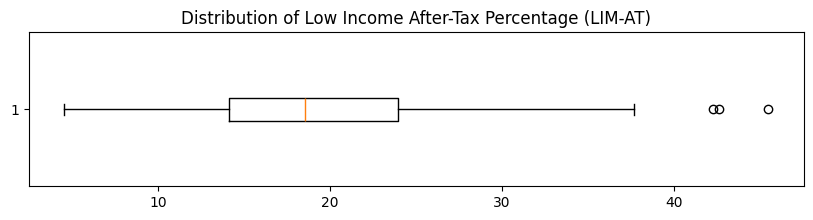

In [52]:
# Boxplot of LIM-AT

plt.figure(figsize=(10,2))

plt.boxplot(
    y,
    vert=False)

plt.title("Distribution of Low Income After-Tax Percentage (LIM-AT)")

plt.show()

## Interpretation

The target variable, **Low Income After-Tax Percentage (LIM-AT)**, was examined prior to predictive modelling to assess its distribution and suitability as a response variable.

The modelling dataset contains **140 neighbourhood observations**. The average neighbourhood low-income prevalence is **19.51%**, with a median of **18.55%** and a standard deviation of **7.89 percentage points**, indicating meaningful variation in socioeconomic vulnerability across Toronto neighbourhoods.

The histogram shows that most neighbourhoods have LIM-AT values between approximately **12% and 25%**, while a smaller number of neighbourhoods exhibit substantially higher levels of low-income prevalence. The distribution is **slightly positively skewed**, reflecting the presence of relatively few high-vulnerability neighbourhoods.

The boxplot identifies several neighbourhoods with comparatively high LIM-AT values. These observations are considered valid neighbourhood characteristics rather than data quality issues and are therefore retained for predictive modelling.

The observed range of LIM-AT values (4.50%–43.95%) demonstrates sufficient variability for predictive modelling and provides quantitative evidence that neighbourhood socioeconomic vulnerability can be modelled as a continuous outcome.

Overall, the exploratory analysis demonstrates that **Low Income After-Tax Percentage (LIM-AT)** provides a suitable continuous response variable and an appropriate quantitative proxy for neighbourhood socioeconomic vulnerability. The observed variability supports the use of supervised regression models to predict neighbourhood vulnerability using socioeconomic indicators.

### Section-10. Train-Test Split

To evaluate the predictive performance of the machine learning models, the modelling dataset is partitioned into **training** and **testing** subsets using a **70:30 split**.

The **training dataset (70%)** is used to train the predictive models, while the **testing dataset (30%)** is reserved for evaluating model performance on previously unseen observations.

A fixed **random state (42)** is specified to ensure that the data partitioning is reproducible.

In [53]:
# Train-Test Split (70/30)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42)

print("=" * 60)
print("TRAIN-TEST SPLIT COMPLETE")
print("=" * 60)

print(f"Training Observations : {X_train.shape[0]}")
print(f"Testing Observations  : {X_test.shape[0]}")

print()
print(f"Training Matrix : {X_train.shape}")
print(f"Testing Matrix  : {X_test.shape}")

TRAIN-TEST SPLIT COMPLETE
Training Observations : 98
Testing Observations  : 42

Training Matrix : (98, 11)
Testing Matrix  : (42, 11)


### Interpretation

The modelling dataset was randomly partitioned into **98 training observations (70%)** and **42 testing observations (30%)**.

The training dataset is used to estimate the predictive models, while the testing dataset provides an independent assessment of model performance using previously unseen neighbourhood observations.

Separating the data in this manner reduces the risk of overfitting and provides a more reliable estimate of the models' ability to generalize to new neighbourhoods.

### Section-11. Feature Standardization

The predictor variables are standardized using **StandardScaler** prior to model training.

Standardization transforms each predictor variable to have a mean of zero and a standard deviation of one, ensuring that variables measured on different scales contribute comparably during model estimation.

To prevent **data leakage**, the scaler is fitted **only on the training dataset** and subsequently applied to both the training and testing datasets.

In [54]:
# Feature Standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("FEATURE STANDARDIZATION COMPLETE")
print("=" * 60)

print(f"Training Matrix : {X_train_scaled.shape}")
print(f"Testing Matrix  : {X_test_scaled.shape}")

# Display first five standardized observations

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns)

display(X_train_scaled_df.head())

FEATURE STANDARDIZATION COMPLETE
Training Matrix : (98, 11)
Testing Matrix  : (42, 11)


,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct
0,-0.219140,-0.133945,-0.389638,-0.250595,0.678847,0.018845,-0.838444,-1.491870,-0.867049,-1.740186,0.095382
1,0.050695,-0.028812,0.323578,-0.795863,0.709747,0.353296,0.656367,-0.836841,0.475641,-0.165477,0.242047
2,0.161804,0.466814,-1.706344,-0.226334,0.197116,-0.813033,-0.877863,-0.567522,-1.103363,-0.897579,-0.154551
3,-0.457230,-0.644590,1.365971,-1.452603,0.811471,0.330939,0.659837,0.757125,1.098650,0.994835,1.961092
4,-2.028623,-1.876147,0.762480,-0.324899,1.362536,1.989783,2.050898,-1.551758,0.282294,0.276547,-0.038131


### Interpretation

The predictor variables were successfully standardized prior to model development.

Standardization ensures that each socioeconomic indicator contributes on a comparable numerical scale, preventing variables with larger magnitudes from disproportionately influencing the predictive models.

Fitting the scaler exclusively on the training data prevents information from the testing dataset from influencing model training, thereby preserving the integrity of the model evaluation process.

### Section-12. Baseline Model 1 – Linear Regression

Linear Regression is selected as the baseline predictive model because it provides a simple, interpretable, and statistically robust approach for predicting continuous outcome variables.

The objective is to estimate neighbourhood socioeconomic vulnerability, measured by the **Low Income After-Tax Percentage (LIM-AT)**, using the selected socioeconomic indicators.

This model serves as a benchmark against which more complex machine learning algorithms will later be compared.

In [55]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train)

print("=" * 60)
print("LINEAR REGRESSION MODEL TRAINED")
print("=" * 60)

print("Model training completed successfully.")

LINEAR REGRESSION MODEL TRAINED
Model training completed successfully.


In [56]:
# Generate Predictions

y_pred = linear_model.predict(X_test_scaled)

predictions = pd.DataFrame({

    "Actual LIM-AT": y_test.values,
    "Predicted LIM-AT": y_pred})

display(predictions.head())

,Actual LIM-AT,Predicted LIM-AT
0,32.4,33.205440
1,17.6,17.074556
2,22.3,22.453071
3,14.7,14.899839
4,34.7,30.753477


In [57]:
# Linear Regression Performance

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

performance = pd.DataFrame({

    "Metric": [

        "R² Score",
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)"    ],

    "Value": [

        round(r2,3),
        round(mae,3),
        round(mse,3),
        round(rmse,3)    ]})

display(performance)

,Metric,Value
0,R² Score,0.871
1,Mean Absolute Error (MAE),2.196
2,Mean Squared Error (MSE),7.925
3,Root Mean Squared Error (RMSE),2.815


In [58]:
# Adjusted R²

n = len(y_test)           # Number of testing observations
p = X_test.shape[1]       # Number of predictors

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1))

print(f"Adjusted R²: {adjusted_r2:.3f}")

Adjusted R²: 0.823


### Interpretation

The Linear Regression model was successfully trained to predict neighbourhood socioeconomic vulnerability, measured by the **Low Income After-Tax Percentage (LIM-AT)**.

Model performance was evaluated using regression metrics because the dependent variable is continuous.

The model achieved an **R² Score of 0.871**, indicating that approximately **87.1% of the variation** in neighbourhood low-income prevalence can be explained by the selected socioeconomic indicators.

The **Mean Absolute Error (MAE)** of **2.196** indicates that, on average, the model's predictions differ from the observed LIM-AT values by approximately **2.2 percentage points**.

The **Root Mean Squared Error (RMSE)** of **2.815** demonstrates a relatively low prediction error while assigning greater weight to larger deviations between predicted and observed values.

Overall, the Linear Regression model demonstrates strong predictive performance and provides quantitative evidence that neighbourhood socioeconomic characteristics are highly associated with neighbourhood socioeconomic vulnerability. These findings suggest that the selected predictor variables are effective for estimating neighbourhood-level Low Income After-Tax Percentage (LIM-AT).

The Adjusted R² value of 0.823 remains high after accounting for the number of predictor variables included in the model. This indicates that the model retains strong explanatory power while reducing the likelihood that its performance is artificially inflated by the inclusion of multiple predictors.

### Section-13. Actual vs. Predicted Values

The relationship between the observed and predicted **Low Income After-Tax Percentage (LIM-AT)** values is visualized to assess model accuracy.

If the predictive model performs well, the predicted values should lie close to the 45-degree reference line, indicating strong agreement between observed and predicted neighbourhood vulnerability.

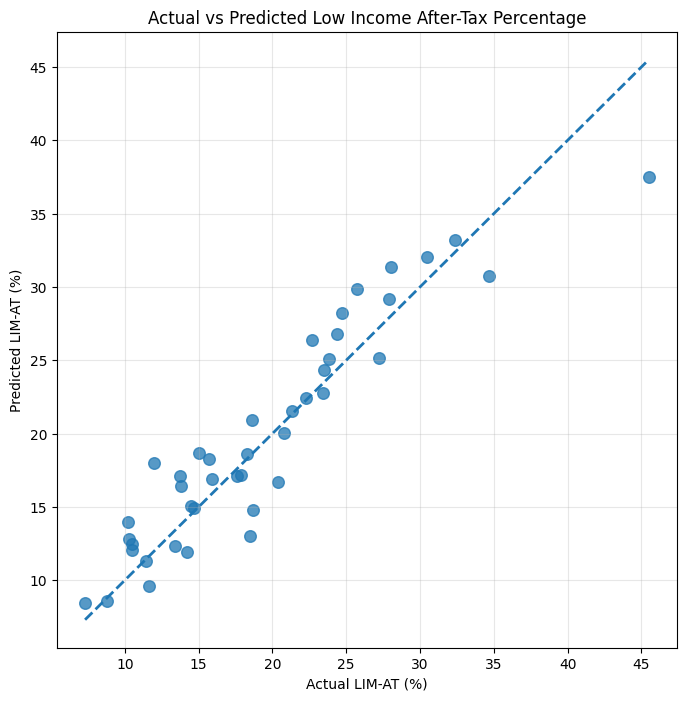

In [59]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.75,
    s=70)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2)

plt.xlabel("Actual LIM-AT (%)")
plt.ylabel("Predicted LIM-AT (%)")
plt.title("Actual vs Predicted Low Income After-Tax Percentage")

plt.grid(alpha=0.3)

plt.show()

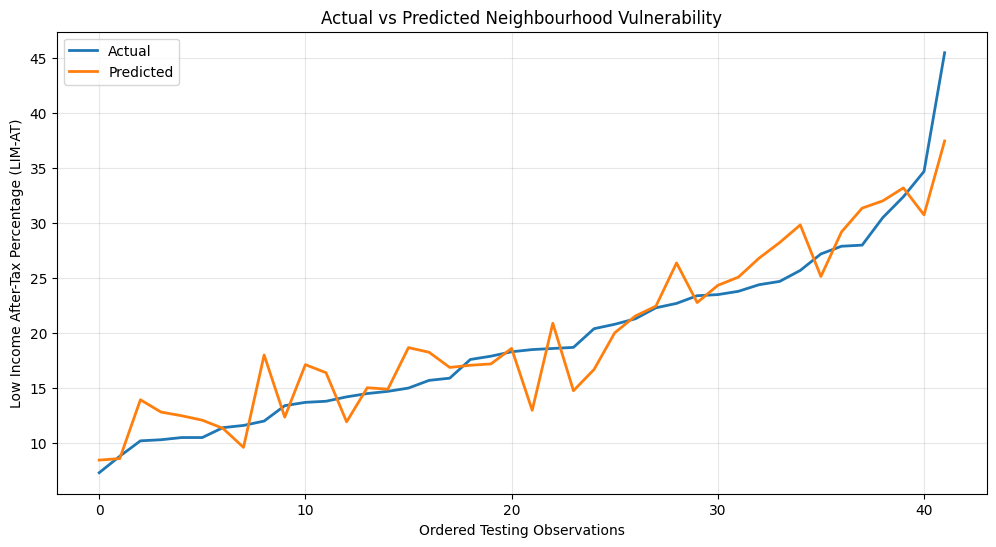

In [60]:
# Actual vs Predicted Line Chart

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred})

comparison = comparison.sort_values("Actual").reset_index(drop=True)

plt.figure(figsize=(12,6))

plt.plot(
    comparison["Actual"],
    label="Actual",
    linewidth=2)

plt.plot(
    comparison["Predicted"],
    label="Predicted",
    linewidth=2)

plt.xlabel("Ordered Testing Observations")
plt.ylabel("Low Income After-Tax Percentage (LIM-AT)")
plt.title("Actual vs Predicted Neighbourhood Vulnerability")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Interpretation

The scatter plot demonstrates a strong linear agreement between the observed and predicted neighbourhood **Low Income After-Tax Percentage (LIM-AT)** values.

Most neighbourhood observations lie close to the **45-degree reference line**, indicating that the Linear Regression model predicts neighbourhood socioeconomic vulnerability with a high degree of accuracy.

Only a small number of neighbourhoods exhibit larger prediction errors, primarily among neighbourhoods with the highest observed LIM-AT values. This behaviour is consistent with the model evaluation metrics, including an **R² Score of 0.871**, indicating that approximately **87.1%** of the variation in neighbourhood low-income prevalence is explained by the selected socioeconomic indicators.

Overall, the scatter plot provides strong visual evidence that the Linear Regression model produces reliable predictions across the majority of Toronto neighbourhoods.

### Section-14. Feature Importance

Linear Regression estimates a coefficient for each predictor variable, representing the expected change in neighbourhood **Low Income After-Tax Percentage (LIM-AT)** associated with a one-unit increase in the standardized predictor, while holding all other variables constant.

Positive coefficients indicate that an increase in the predictor is associated with **higher neighbourhood socioeconomic vulnerability**, whereas negative coefficients indicate an association with **lower neighbourhood socioeconomic vulnerability**.

Examining the regression coefficients provides insight into the relative contribution of each socioeconomic indicator to the predictive model.

In [61]:
# Linear Regression Coefficients

coefficients = pd.DataFrame({

    "Variable": predictor_variables,
    "Coefficient": linear_model.coef_})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs())

coefficients = (
    coefficients
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    .reset_index(drop=True))

coefficients.insert(
    0,
    "Rank",
    range(1, len(coefficients)+1))

display(coefficients.round(3))

,Rank,Variable,Coefficient,Absolute Coefficient
0,1,Employment_Rate,17.816,17.816
1,2,Participation_Rate,-17.613,17.613
2,3,Unemployment_Rate,4.743,4.743
3,4,Renters_Pct,3.130,3.130
4,5,Unaffordable_Housing,3.120,3.120
5,6,Visible_Minority_Pct,2.955,2.955
6,7,Immigrant_Population_Pct,-2.141,2.141
7,8,Lone_Parent_Families_Pct,1.266,1.266
8,9,No_Diploma_Pct,-0.371,0.371
9,10,Bachelors_Degree_Pct,-0.286,0.286


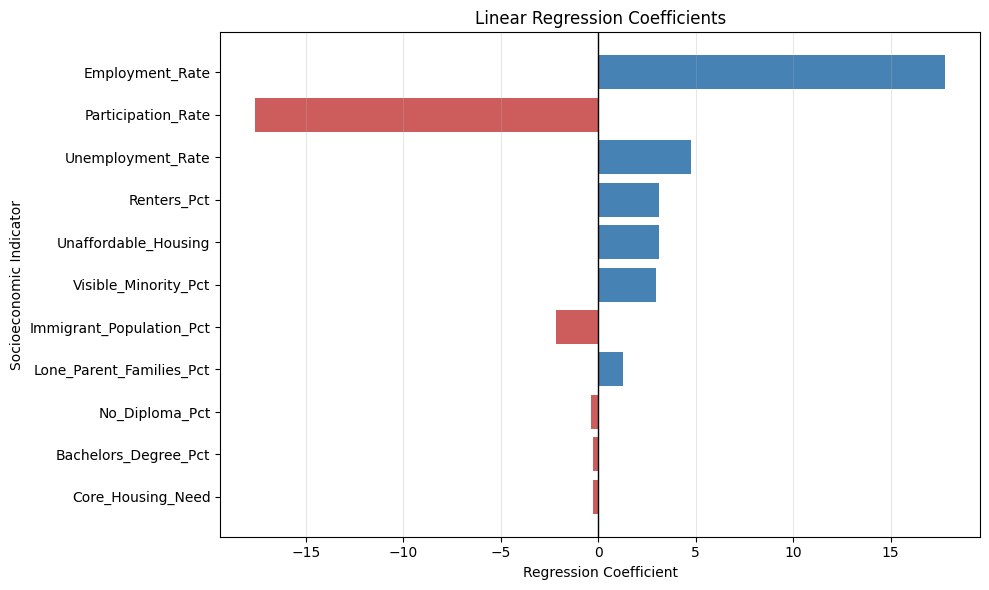

In [62]:
# Feature Importance Plot

colors = [
    "steelblue" if coef >= 0 else "indianred"
    for coef in coefficients["Coefficient"]]

plt.figure(figsize=(10,6))

plt.barh(
    coefficients["Variable"],
    coefficients["Coefficient"],
    color=colors)

plt.axvline(0, color="black", linewidth=1)

plt.title("Linear Regression Coefficients")
plt.xlabel("Regression Coefficient")
plt.ylabel("Socioeconomic Indicator")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The standardized regression coefficients quantify the relative contribution of each socioeconomic indicator to the prediction of neighbourhood **Low Income After-Tax Percentage (LIM-AT)** after accounting for the effects of all remaining predictors.

The largest absolute coefficients were observed for:

- **Employment Rate** (17.816)
- **Participation Rate** (-17.613)
- **Unemployment Rate** (4.743)
- **Renters (%)** (3.130)
- **Unaffordable Housing** (3.120)
- **Visible Minority (%)** (2.955)

These findings indicate that labour market characteristics represent the strongest predictors of neighbourhood socioeconomic vulnerability within the Linear Regression model, followed by housing and demographic characteristics.

Variables such as **Bachelor's Degree (%)**, **No Diploma (%)**, and **Core Housing Need** exhibited comparatively small coefficients after controlling for the remaining socioeconomic indicators, suggesting a more limited independent contribution to the model.

Because the regression coefficients represent conditional relationships after adjusting for all other predictors, their direction and magnitude may differ from the pairwise correlations reported in Notebook 2. This behaviour is expected in multiple regression when predictor variables are correlated.

Overall, the coefficient analysis demonstrates that employment, labour force participation, housing affordability, and renter concentration are the most influential socioeconomic indicators contributing to the prediction of neighbourhood vulnerability.

### Section 15- Baseline Model 2 – Random Forest Regression

Random Forest Regression is developed as a second predictive model to compare its performance with the baseline Linear Regression model.

Unlike Linear Regression, Random Forest is a non-parametric ensemble learning algorithm capable of capturing complex and non-linear relationships between socioeconomic indicators and neighbourhood vulnerability.

The objective is to determine whether a more flexible machine learning algorithm improves prediction accuracy for neighbourhood **Low Income After-Tax Percentage (LIM-AT)**.

In [63]:
# Train Random Forest Regression Model

random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42)

random_forest.fit(
    X_train,
    y_train)

print("=" * 60)
print("RANDOM FOREST MODEL TRAINED")
print("=" * 60)

print("Model training completed successfully.")

RANDOM FOREST MODEL TRAINED
Model training completed successfully.


In [64]:
# Random Forest Predictions

rf_predictions = random_forest.predict(X_test)

display(pd.DataFrame({

    "Actual LIM-AT": y_test.values,
    "Predicted LIM-AT": rf_predictions}).head())

,Actual LIM-AT,Predicted LIM-AT
0,32.4,27.5610
1,17.6,17.6670
2,22.3,22.1325
3,14.7,15.8785
4,34.7,27.9365


In [65]:
# Random Forest Performance

rf_r2 = r2_score(y_test, rf_predictions)

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_performance = pd.DataFrame({

    "Metric":[

        "R² Score",
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)"    ],

    "Value":[

        round(rf_r2,3),
        round(rf_mae,3),
        round(rf_mse,3),
        round(rf_rmse,3)    ]})

display(rf_performance)

,Metric,Value
0,R² Score,0.816
1,Mean Absolute Error (MAE),2.545
2,Mean Squared Error (MSE),11.262
3,Root Mean Squared Error (RMSE),3.356


In [66]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({

    "Variable": predictor_variables,
    "Importance": random_forest.feature_importances_})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True))

rf_importance.insert(
    0,
    "Rank",
    range(1, len(rf_importance) + 1))

display(rf_importance.round(3))

,Rank,Variable,Importance
0,1,Unemployment_Rate,0.389
1,2,Unaffordable_Housing,0.228
2,3,Renters_Pct,0.160
3,4,Visible_Minority_Pct,0.094
4,5,Core_Housing_Need,0.040
5,6,Lone_Parent_Families_Pct,0.023
6,7,Employment_Rate,0.019
7,8,No_Diploma_Pct,0.012
8,9,Immigrant_Population_Pct,0.012
9,10,Participation_Rate,0.011


### Interpretation

The Random Forest Regression model was successfully trained to predict neighbourhood **Low Income After-Tax Percentage (LIM-AT)** using the selected socioeconomic indicators.

The model achieved an **R² Score of 0.816**, indicating that approximately **81.6%** of the variation in neighbourhood socioeconomic vulnerability can be explained by the predictor variables. The model produced a **Mean Absolute Error (MAE)** of **2.545** percentage points and a **Root Mean Squared Error (RMSE)** of **3.356** percentage points.

Overall, the Random Forest model demonstrated strong predictive capability, producing relatively accurate estimates of neighbourhood low-income prevalence across the testing dataset. However, compared with the baseline Linear Regression model, Random Forest exhibited slightly lower explanatory power and larger prediction errors.

These findings suggest that, for the current dataset, the relationships between the selected socioeconomic indicators and neighbourhood vulnerability are predominantly linear. Consequently, the additional flexibility of the Random Forest algorithm did not translate into improved predictive performance.

The Random Forest model nevertheless provides a valuable benchmark for comparison and confirms that the selected socioeconomic indicators contain substantial predictive information regarding neighbourhood socioeconomic vulnerability.

### Section-16. Model Comparison

To determine the most appropriate predictive model for estimating neighbourhood socioeconomic vulnerability, the performance of the **Linear Regression** and **Random Forest Regression** models is compared using common regression evaluation metrics.

Model performance is evaluated using:

- **R² Score** – proportion of variation in neighbourhood vulnerability explained by the model.
- **Adjusted R²** – explanatory power adjusted for the number of predictor variables.
- **Mean Absolute Error (MAE)** – average prediction error.
- **Root Mean Squared Error (RMSE)** – overall prediction error with greater emphasis on larger errors.
- **Mean Squared Error (MSE)** – average squared prediction error.

The model demonstrating the highest explanatory power together with the lowest prediction errors is considered the preferred predictive model.

In [67]:
# Model Performance Comparison

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest Regression"    ],

    "R²":[
        round(r2,3),
        round(rf_r2,3)    ],

    "Adjusted R²":[
        round(adjusted_r2,3),
                        np.nan    ],

    "MAE":[
        round(mae,3),
        round(rf_mae,3)    ],

    "RMSE":[
        round(rmse,3),
        round(rf_rmse,3)   ],

    "MSE":[
        round(mse,3),
        round(rf_mse,3)    ]})

display(comparison)

,Model,R²,Adjusted R²,MAE,RMSE,MSE
0,Linear Regression,0.871,0.823,2.196,2.815,7.925
1,Random Forest Regression,0.816,NaN,2.545,3.356,11.262


## Interpretation

The predictive performance of the **Linear Regression** and **Random Forest Regression** models was evaluated using the coefficient of determination (**R²**), **Adjusted R²**, **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **Mean Squared Error (MSE)**.

The results indicate that **Linear Regression consistently outperformed Random Forest Regression across all evaluation metrics**.

Linear Regression achieved the highest explanatory power with an **R² Score of 0.871**, indicating that approximately **87.1%** of the variation in neighbourhood **Low Income After-Tax Percentage (LIM-AT)** was explained by the selected socioeconomic indicators. After accounting for model complexity, the **Adjusted R² remained high (0.823)**, demonstrating that the model retained strong explanatory power without evidence of substantial overfitting.

In comparison, the Random Forest Regression model achieved an **R² Score of 0.816**, explaining **81.6%** of the variation in neighbourhood vulnerability. Although this represents strong predictive performance, it was consistently less accurate than the Linear Regression model.

Prediction error metrics further support this conclusion. Linear Regression produced the lowest **Mean Absolute Error (2.196)**, **Root Mean Squared Error (2.815)**, and **Mean Squared Error (7.925)**, whereas Random Forest Regression resulted in larger prediction errors (**MAE = 2.545**, **RMSE = 3.356**, **MSE = 11.262**).

These findings suggest that the relationship between the selected socioeconomic indicators and neighbourhood vulnerability is predominantly linear. Consequently, the simpler Linear Regression model provides both superior predictive accuracy and greater interpretability than the more complex Random Forest Regression model for this dataset.

Based on these results, **Linear Regression was selected as the final predictive model for estimating neighbourhood socioeconomic vulnerability in Toronto neighbourhoods.**

### Section-17 Study Limitations and Future Work

Although the predictive modelling framework produced strong results, several limitations should be acknowledged.

First, the analysis was conducted using the **Toronto Neighbourhood Profile 2016** dataset. Consequently, the predictive models represent neighbourhood socioeconomic conditions for a single point in time and cannot capture changes in neighbourhood vulnerability over multiple years.

Second, the study relies on aggregated neighbourhood-level indicators rather than household-level information. While neighbourhood averages provide valuable insights for municipal planning, they may not fully represent socioeconomic variation within individual neighbourhoods.

Third, although the selected socioeconomic indicators explained a substantial proportion of neighbourhood low-income prevalence, additional variables such as housing prices, crime rates, access to public transit, health indicators, and economic development measures may further improve predictive performance.

Future work will extend the analysis by incorporating the **2006** and **2011 Toronto Neighbourhood Profile datasets**, allowing longitudinal modelling of neighbourhood socioeconomic vulnerability over time. This extension will support the development of temporal prediction models capable of identifying neighbourhoods experiencing increasing or decreasing socioeconomic vulnerability.

Additional machine learning techniques, including Gradient Boosting, XGBoost, and ensemble modelling approaches, may also be investigated to evaluate whether predictive performance can be further improved.

### Section-18
### Overall Conclusion

This notebook developed and evaluated supervised machine learning models to predict neighbourhood socioeconomic vulnerability, measured by the **Low Income After-Tax Percentage (LIM-AT)**, using selected socioeconomic indicators.

Two predictive models were constructed and compared: **Linear Regression** and **Random Forest Regression**. Model performance was assessed using R², Adjusted R², Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Squared Error (MSE).

The results demonstrated that **Linear Regression provided the strongest predictive performance**, explaining approximately **87.1%** of the variation in neighbourhood low-income prevalence while maintaining relatively low prediction errors. Although Random Forest Regression also performed well, its predictive accuracy was consistently lower across all evaluation metrics.

Feature importance analysis further demonstrated that labour market conditions, housing affordability, renter concentration, and demographic characteristics are among the most influential predictors of neighbourhood socioeconomic vulnerability.

Overall, the findings demonstrate that neighbourhood socioeconomic vulnerability can be accurately estimated using a relatively small set of socioeconomic indicators. These results support the application of predictive analytics as a decision-support tool for municipal planners, policymakers, housing organizations, and community agencies seeking to identify neighbourhoods at elevated socioeconomic risk and allocate resources more effectively.

In [68]:
# Export Prediction Results

prediction_results = pd.DataFrame({
    "Actual_LIM_AT": y_test.values,
    "Predicted_LIM_AT_Linear": y_pred,
    "Predicted_LIM_AT_RF": rf_predictions})

prediction_results.head()

,Actual_LIM_AT,Predicted_LIM_AT_Linear,Predicted_LIM_AT_RF
0,32.4,33.205440,27.5610
1,17.6,17.074556,17.6670
2,22.3,22.453071,22.1325
3,14.7,14.899839,15.8785
4,34.7,30.753477,27.9365


### Section-19. Export final results

In [69]:
# Export Prediction Results
prediction_results = pd.DataFrame({
    "Actual_LIM_AT": y_test.values,
    "Predicted_LIM_AT_Linear": y_pred,
    "Predicted_LIM_AT_RF": rf_predictions})

prediction_results.head()

,Actual_LIM_AT,Predicted_LIM_AT_Linear,Predicted_LIM_AT_RF
0,32.4,33.205440,27.5610
1,17.6,17.074556,17.6670
2,22.3,22.453071,22.1325
3,14.7,14.899839,15.8785
4,34.7,30.753477,27.9365


In [70]:
# Standardize Entire Predictor Dataset

X_scaled = scaler.transform(X)
# Add Linear Regression Predictions

df["Linear_Regression_Prediction"] = linear_model.predict(X_scaled)

# Add Random Forest Predictions

df["Random_Forest_Prediction"] = random_forest.predict(X)

display(df.head())

,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct,Low_Income_AfterTax_Pct,Linear_Regression_Prediction,Random_Forest_Prediction
0,Agincourt North,29113,55.4,50.0,9.8,15.044825,25.624292,68.680658,90.560918,5.908014,2220,34.7,5.667571,21.3,21.551038,20.4710
1,Agincourt South-Malvern West,23757,59.0,53.2,9.8,17.721093,25.634550,63.539167,84.838153,9.470893,1795,38.2,5.724629,22.6,22.826951,22.2120
2,Alderwood,12054,66.5,62.4,6.1,13.771362,24.556164,32.935125,20.657043,7.881201,540,21.7,5.558321,8.2,5.691611,7.9195
3,Annex,30526,70.6,65.8,6.7,29.925310,13.988076,27.091660,23.815764,32.333093,2420,40.4,2.931927,18.3,20.528937,18.4265
4,Banbury-Don Mills,27695,59.9,55.6,7.2,23.469940,18.595414,47.643979,45.856653,17.096949,2115,33.4,4.531504,13.7,17.129590,17.9345


In [71]:
# Export Results

reports_path = project_root / "reports"
processed_path = project_root / "data" / "processed"

reports_path.mkdir(exist_ok=True)
processed_path.mkdir(exist_ok=True)

output_excel = reports_path / "04_Predictive_Modelling_Results.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:

    performance.to_excel(
        writer,
        sheet_name="Linear Regression",
        index=False    )

    rf_performance.to_excel(
        writer,
        sheet_name="Random Forest",
        index=False    )

    comparison.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False    )

    coefficients.to_excel(
        writer,
        sheet_name="Regression Coefficients",
        index=False    )

    # Change this variable if your notebook uses a different name
    rf_importance.to_excel(
        writer,
        sheet_name="RF Importance",
        index=False    )

    prediction_results.to_excel(
        writer,
        sheet_name="Predictions",
        index=False    )

df.to_csv(
    processed_path / "neighbourhood_profiles_2016_predictions.csv",
    index=False)

print("=" * 60)
print("EXPORT COMPLETED SUCCESSFULLY")
print("=" * 60)
print(output_excel)

EXPORT COMPLETED SUCCESSFULLY
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project\reports\04_Predictive_Modelling_Results.xlsx
